# KNN Classifier: Distinguishing 6s and 7s from MNIST

## 1. Environment Check

In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

libs = ["numpy", "sklearn", "matplotlib", "pandas"]

for lib in libs:
    spec = importlib.util.find_spec(lib)
    print(f'spec: {spec}')
    if spec:
        mod = importlib.import_module(lib)
        version = getattr(mod, "__version__", "found (no version attr)")
        print(f"✅ {lib}: {version}")
    else:
        print(f"❌ {lib}: NOT installed")

spec: ModuleSpec(name='numpy', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000001E912F22570>, origin='c:\\Users\\fjfra\\miniforge3\\envs\\datasci\\Lib\\site-packages\\numpy\\__init__.py', submodule_search_locations=['c:\\Users\\fjfra\\miniforge3\\envs\\datasci\\Lib\\site-packages\\numpy'])
✅ numpy: 2.3.3
spec: ModuleSpec(name='sklearn', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000001E912EDEDB0>, origin='c:\\Users\\fjfra\\miniforge3\\envs\\datasci\\Lib\\site-packages\\sklearn\\__init__.py', submodule_search_locations=['c:\\Users\\fjfra\\miniforge3\\envs\\datasci\\Lib\\site-packages\\sklearn'])
✅ sklearn: 1.7.2
spec: ModuleSpec(name='matplotlib', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000001E912F22000>, origin='c:\\Users\\fjfra\\miniforge3\\envs\\datasci\\Lib\\site-packages\\matplotlib\\__init__.py', submodule_search_locations=['c:\\Users\\fjfra\\miniforge3\\envs\\datasci\\Lib\\site-packages\\matplotlib'])
✅ matplotlib: 

## 2. Loading the Data

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, as_frame=False)

print(type(mnist))
print(mnist.keys())
print(mnist.data.shape)
print(mnist.target.shape)

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])
(70000, 784)
(70000,)


## 3. Filtering for `'6'`s and `'7's`

In [3]:
mask = (mnist.target == '6') | (mnist.target == '7')
print(f'mask: {mask}')

training_67 = mnist.data[mask]
labels_67 = mnist.target[mask]

print(f'training shape: {training_67.shape}')
print(f'testing shape: {labels_67.shape}')

mask: [False False False ... False False  True]
training shape: (14169, 784)
testing shape: (14169,)


## 4. Visualizing the Data

I'm working with the mnist data set, it contains **70,000 unique images of hand-drawn digits**. I'm also learning about K Nearest Neighbor (KNN) models and how they are helpful for classification. As a skill check, I wanted to see if I could **create an accurate KNN model to distinguish between just two labels, `'6'` and `'7'`** (Why these two numbers in particular? They seemed particularly relevant in my social feeds). 

While the mnist data set is based off hand-drawn digits in 28x28 image format, they don't appear that way after importing them. Instead, **each image has been flattened into a 1D array with 784 features** wherein each pixel's brightness is its own feature (28x28 pixels = 784) and all share the same range so no need for scaling features . **Visualizing the data as the images it originated is possible by reshaping each row back into a 28x28 matrix** that can be graphed using `matplotlib.pyplot`.

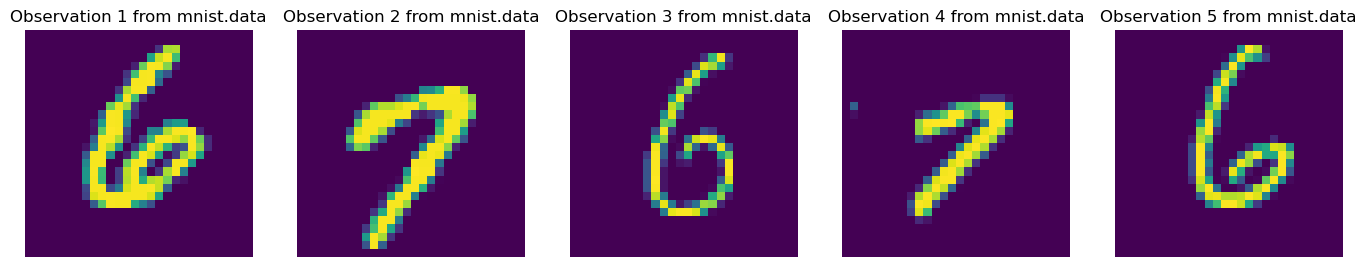

In [4]:
fig, axes = plt.subplots(1, 5, figsize = (17,3))
for i in range(5):
    reshaped = np.reshape(training_67[i], (28,28))
    axes[i].imshow(reshaped)
    axes[i].axis('off')
    axes[i].set_title(f'Observation {i+1} from mnist.data')


## 5. Train/Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(training_67, labels_67, test_size = .2, random_state = 67)

print(f'X_train shape: {X_train.shape}\nX_test: {X_test.shape}')
print(f'y_train shape: {y_train.shape}\ny_test: {y_test.shape}')

X_train shape: (11335, 784)
X_test: (2834, 784)
y_train shape: (11335,)
y_test: (2834,)


In [14]:
# sanity check
X_test.shape[0]/ (X_test.shape[0] + X_train.shape[0])

0.20001411532218222

## 6. Building the KNN Model

Now that the dataset has been split into a training and testing portion, the KNN model can finally take shape. **KNN are considered "lazy" models in that they leave the majority of computation to prediction runtime**. This is because of how they work. 

"Training" for this model is it memorizing the feature values and corresponding labels for each training observation so distance for that class to our input observation during our prediction can be computed. The smaller the distance, means the more similar the feature values are between our input and the training observation meaning that they are likely of the same class. Tally K number labels from the K nearest neighbors to our input from our training data, and the prediction is whichever is the most common!

In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(f'y_pred shape: {y_pred.shape}')

y_pred shape: (2834,)


## 7. Evaluation

Using `.score()` and `confusion_matrix()`, we can quickly see how accurate the model is and where it messes up respectively. Our model scored 0.999... which on a scale from 0.0 to 1.0 tells us that our **model is extremely accurate**. As for the confusion matrix, we see that our model correctly identified 1361 `'6'`s, correctly identified 1472 `'7'`s, falsely identifed 0 `'6'`s as `'7'`s, **only falsely identified 1 `'7'` as a `'6'`**. 

KNN score: 0.9996471418489767


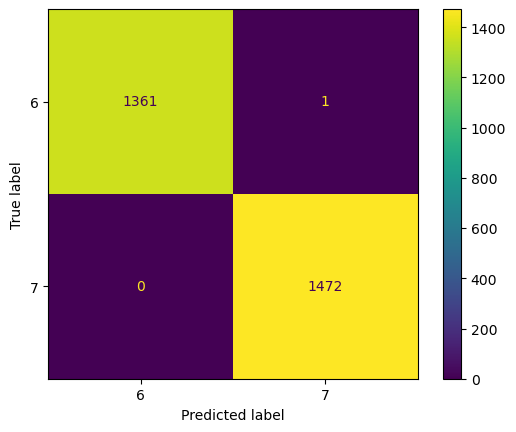

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(f'KNN score: {knn.score(X_test, y_test)}')
cm = confusion_matrix(y_test, y_pred, labels = knn.classes_)
confusion_display = ConfusionMatrixDisplay(cm, display_labels = knn.classes_)
confusion_display.plot()
plt.show()

The rogue prediction...does look like a `'6'` from a glance, but our model mistook it for a `'7'`.

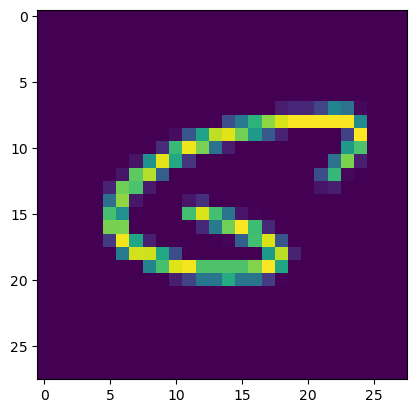

In [25]:
rogue_pred = X_test[np.where(y_pred!= y_test)]
plt.imshow(np.reshape(rogue_pred, (28,28)))

## 8. Optimizing K

At this point, it's a good idea to ask, "Does our model improve by changing the K value?" 

We should ask this question because K is the number of closest neighbors we check. The more we check then the more prone our model is to predicting the label that is most common in the data overall. The less we check then the model is more susceptible to outliers. We should use a K-value with a happy middle ground. 

**To find this optimal middle ground, we'll train and evaluate models across K-values 1 through 20 and compare their accuracy on the test set.**

In [43]:
K_accuracy = []

for i in range(1,21):
    knn_i = KNeighborsClassifier(n_neighbors = i)
    knn_i.fit(X_train, y_train)
    K_accuracy.append(knn_i.score(X_test, y_test))

K_accuracy = np.asarray(K_accuracy)

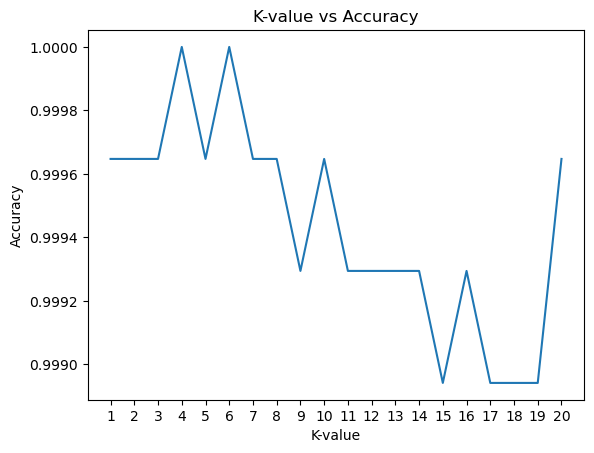

In [49]:
plt.xticks(np.arange(1, 21))
plt.title('K-value vs Accuracy')
plt.xlabel('K-value')
plt.ylabel('Accuracy')
plt.plot(np.arange(1,21), K_accuracy)

Looking at the K-values and their respective accuracy on the testing data we see two peaks at K = 4 and K = 6 with both scoring perfectly. Although, I would like to mention that all of these K-values make great predictions. As such, I was hesitant to jump on declaring 4 or 6 the best value for K since I understand that the task of classifying a `'6'` or a `'7'` is binary and it is generally better to have an odd K-value. 

Having an **odd K-value ensures there are no ties when it comes to tallying the nearest neighbor labels. However, I think this is an exception, `'6'` and `'7'` are very distinct labels visually (little overlap in pixels in images)** and the KNN model from `sklearn` is robust in how it resolves ties. Instead of doing a coinflip between the tied labels, it picks the tied label with the closest point to the input. This is exactly why these two models were perfectly accurate, they leveraged this closest datapoint to break the tie and did so accurately. 

With this in mind, **I am confident in saying that 4 or 6 are the best values for K**. 

## 9. Closing Thoughts

Reflecting on this learning experiment, I have taught a machine the vital skill of distinguishing a `6` from a `7` flawlessly on a testing set of 2834 examples. 

On a more serious note, I have gleaned a lot of knowledge on KNNs in how they work, what they are used to predict, and now can confidently build them and optimize their predictions using `sklearn`, `numpy`, and `matplotlib`. One thing I was especially shocked to see and learn was how our even number K-values scored better than the odd number ones despite the opposite generally being true in binary classification. 

Perhaps we would see odd number K-values performing better if our training and testing data was shuffled. This idea leads to K-fold cross validation, where we could see how the same model performs when tested in a round robin manner. The entire dataset is divided into equally large K chunks where K-1 chunks are used as the training set and tested on the remaining chunk with its accuracy recorded. Then the testing chunk is integrated back into the training set and one of the training chunks is used as the testing chunk until each has been able to be used as the testing chunk. 

In the future I would like to explore K-fold cross validation and including more digits to be classified, such as 3 and 8. These 2 digits are very visually similar so I imagine with human handwriting it would lead to lots of pixel overlap and confuse the model. 